## Ethereum training for XGBoost model

In [1]:
import pandas as pd
import numpy as np
import random

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

random.seed(42)
np.random.seed(42)

In [2]:
eth_df_xgb = pd.read_csv(r'feature_datasets\ETH_features.csv', parse_dates=True, index_col=0)

print(eth_df_xgb.shape)
eth_df_xgb.head()

(916, 30)


,Close,High,Low,Open,Volume,Daily_Return,Close_Lag_1,Close_Lag_7,Close_Lag_14,Close_Lag_30,...,HL_Spread,Volume_MA_7,Volume_MA_21,Volume_MA_60,Volume_MA_180,Volume_Change,Target_Return_7,Target_Return_30,Target_Return_365,Target_Up
Date,,,,,,,,,,,,,,,,,,,,,
2021-06-30,2274.547607,2282.989014,2090.760742,2164.216309,2.582806e+10,0.052657,2160.768311,1989.736328,2367.663574,2714.945312,...,192.228271,2.281828e+10,2.523003e+10,3.825211e+10,3.458739e+10,0.040819,0.017856,0.084594,-0.530764,1
2021-07-01,2113.605469,2274.397461,2081.081055,2274.397461,2.906170e+10,-0.070758,2274.547607,1988.456299,2372.001953,2633.518311,...,193.316406,2.407383e+10,2.524470e+10,3.826927e+10,3.463917e+10,0.125199,0.003038,0.199945,-0.498597,1
2021-07-02,2150.040283,2155.596436,2021.824829,2109.892578,3.179621e+10,0.017238,2113.605469,1813.217285,2231.733154,2706.125000,...,133.771606,2.536267e+10,2.557630e+10,3.797964e+10,3.456470e+10,0.094093,-0.001557,0.191537,-0.503957,0
2021-07-03,2226.114258,2237.567139,2117.590088,2150.834961,1.743336e+10,0.035383,2150.040283,1829.239258,2178.499023,2855.126465,...,119.977051,2.490493e+10,2.518149e+10,3.723016e+10,3.434519e+10,-0.451716,-0.051530,0.172515,-0.517650,0
2021-07-04,2321.724121,2384.286865,2190.837646,2226.550293,1.878711e+10,0.042949,2226.114258,1978.894653,2246.364502,2688.195068,...,193.449219,2.474802e+10,2.478597e+10,3.673771e+10,3.421880e+10,0.077653,-0.078416,0.077798,-0.504222,0


In [3]:
# Target = next-day Close
eth_y_xgb = eth_df_xgb['Close'].shift(-1)

# Features = all columns except Close
eth_X_xgb = eth_df_xgb.drop(columns=['Close'])

# Drop last row because shifted target becomes NaN
eth_X_xgb = eth_X_xgb.iloc[:-1]
eth_y_xgb = eth_y_xgb.iloc[:-1]

print("ETH X shape:", eth_X_xgb.shape)
print("ETH y shape:", eth_y_xgb.shape)

ETH X shape: (915, 29)
ETH y shape: (915,)


In [4]:
split_idx = int(len(eth_X_xgb) * 0.7)

eth_X_train_xgb = eth_X_xgb.iloc[:split_idx]
eth_X_test_xgb = eth_X_xgb.iloc[split_idx:]

eth_y_train_xgb = eth_y_xgb.iloc[:split_idx]
eth_y_test_xgb = eth_y_xgb.iloc[split_idx:]

print("X_train shape:", eth_X_train_xgb.shape)
print("X_test shape:", eth_X_test_xgb.shape)
print("y_train shape:", eth_y_train_xgb.shape)
print("y_test shape:", eth_y_test_xgb.shape)

X_train shape: (640, 29)
X_test shape: (275, 29)
y_train shape: (640,)
y_test shape: (275,)


In [5]:
model_xgb = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

model_xgb.fit(eth_X_train_xgb, eth_y_train_xgb)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [6]:
eth_preds_xgb = model_xgb.predict(eth_X_test_xgb)

print("Predictions shape:", eth_preds_xgb.shape)
print("First 10 predictions:", eth_preds_xgb[:10])

Predictions shape: (275,)
First 10 predictions: [1807.5724 1781.4097 1785.694  1790.0427 1880.9587 1845.7605 1791.6667
 1809.9968 1795.384  1800.7804]


In [8]:
mse_xgb = mean_squared_error(eth_y_test_xgb, eth_preds_xgb)
rmse_xgb = np.sqrt(mse_xgb)
mae_xgb = mean_absolute_error(eth_y_test_xgb, eth_preds_xgb)
r2_xgb = r2_score(eth_y_test_xgb, eth_preds_xgb)
mape_xgb = np.mean(np.abs((eth_y_test_xgb - eth_preds_xgb) / eth_y_test_xgb)) * 100

print("XGBoost Results:")
print(f"MSE: {mse_xgb:.2f}")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"MAE: {mae_xgb:.2f}")
print(f"R2 Score: {r2_xgb:.4f}")
print(f"MAPE: {mape_xgb:.2f}%")

XGBoost Results:
MSE: 4717.06
RMSE: 68.68
MAE: 53.98
R2 Score: 0.8781
MAPE: 2.84%


In [9]:
results_xgb = pd.DataFrame({
    "Actual": eth_y_test_xgb.values,
    "Predicted": eth_preds_xgb
})

results_xgb.head()

,Actual,Predicted
0,1795.708130,1807.572388
1,1810.297119,1781.409668
2,1871.005127,1785.693970
3,1909.114014,1790.042725
4,1872.922607,1880.958740


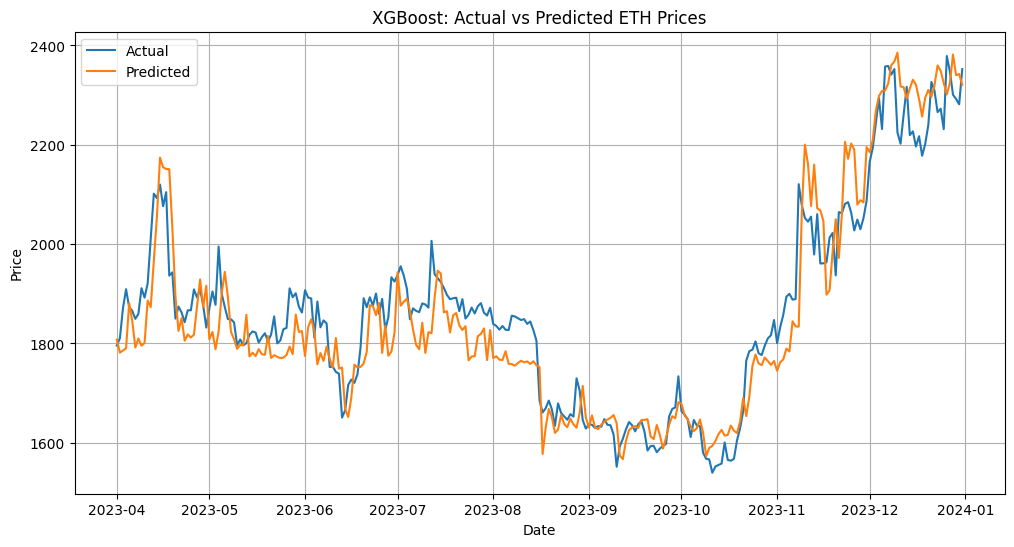

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(eth_y_test_xgb.index,eth_y_test_xgb.values, label="Actual")
plt.plot(eth_y_test_xgb.index,eth_preds_xgb, label="Predicted")
plt.title("XGBoost: Actual vs Predicted ETH Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

              Feature  Importance
1                 Low    0.429657
0                High    0.337257
2                Open    0.114648
27  Target_Return_365    0.038519
11               MA_7    0.034558
5         Close_Lag_1    0.011927
12              MA_21    0.005304
10      Close_Lag_180    0.003123
14             MA_180    0.002783
21       Volume_MA_21    0.002579


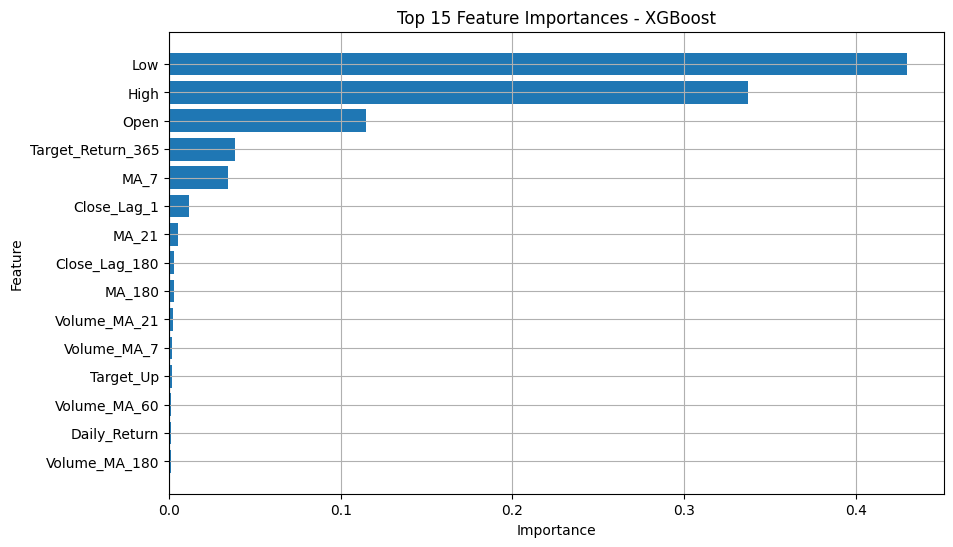

In [11]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": eth_X_train_xgb.columns,
    "Importance": model_xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance.head(10))

plt.figure(figsize=(10, 6))
plt.barh(importance["Feature"].head(15)[::-1], importance["Importance"].head(15)[::-1])
plt.title("Top 15 Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(True)
plt.show()

## Finetuning Xgboost model

In [12]:
import optuna
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 100, 500)
    max_depth = trial.suggest_int("max_depth", 3, 10)
    learning_rate = trial.suggest_float("learning_rate", 1e-3, 0.3, log=True)
    subsample = trial.suggest_float("subsample", 0.6, 1.0)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0)

    model_xgb_opt = XGBRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        objective="reg:squarederror",
        random_state=42
    )

    model_xgb_opt.fit(eth_X_train_xgb, eth_y_train_xgb)

    preds_xgb_opt = model_xgb_opt.predict(eth_X_test_xgb)

    rmse_xgb_opt = np.sqrt(mean_squared_error(eth_y_test_xgb, preds_xgb_opt))
    return rmse_xgb_opt

c:\Users\tharu\anaconda3\envs\Streamlit\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
study_xgb = optuna.create_study(
    direction="minimize",
    study_name="xgb_optuna_eth",
    storage="sqlite:///xgb_optuna_eth.db",
    load_if_exists=True
)

study_xgb.optimize(objective, n_trials=50)

[I 2026-04-11 13:41:13,736] A new study created in RDB with name: xgb_optuna_eth
[I 2026-04-11 13:41:15,150] Trial 0 finished with value: 74.78273321595779 and parameters: {'n_estimators': 336, 'max_depth': 4, 'learning_rate': 0.02025616182151998, 'subsample': 0.9342630767498368, 'colsample_bytree': 0.9191490342612325}. Best is trial 0 with value: 74.78273321595779.
[I 2026-04-11 13:41:16,073] Trial 1 finished with value: 66.52587745050228 and parameters: {'n_estimators': 413, 'max_depth': 3, 'learning_rate': 0.015586968013418077, 'subsample': 0.8217532446036403, 'colsample_bytree': 0.6353158547131649}. Best is trial 1 with value: 66.52587745050228.
[I 2026-04-11 13:41:17,768] Trial 2 finished with value: 331.0243059687772 and parameters: {'n_estimators': 285, 'max_depth': 8, 'learning_rate': 0.0016236558778598817, 'subsample': 0.946640982689906, 'colsample_bytree': 0.6104146353918481}. Best is trial 1 with value: 66.52587745050228.
[I 2026-04-11 13:41:20,235] Trial 3 finished with val

In [14]:
print("Best XGBoost RMSE:", study_xgb.best_value)
print("Best XGBoost Parameters:", study_xgb.best_params)

Best XGBoost RMSE: 59.62467270361032
Best XGBoost Parameters: {'n_estimators': 304, 'max_depth': 9, 'learning_rate': 0.012331014385922354, 'subsample': 0.6407426819654948, 'colsample_bytree': 0.7590535491901226}


In [15]:
best_params_xgb = study_xgb.best_params

model_xgb_best = XGBRegressor(
    n_estimators=best_params_xgb["n_estimators"],
    max_depth=best_params_xgb["max_depth"],
    learning_rate=best_params_xgb["learning_rate"],
    subsample=best_params_xgb["subsample"],
    colsample_bytree=best_params_xgb["colsample_bytree"],
    objective="reg:squarederror",
    random_state=42
)

model_xgb_best.fit(eth_X_train_xgb, eth_y_train_xgb)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7590535491901226
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import

In [16]:
eth_preds_xgb_best = model_xgb_best.predict(eth_X_test_xgb)

print("Predictions shape:", eth_preds_xgb_best.shape)
print("First 10 predictions:", eth_preds_xgb_best[:10])

Predictions shape: (275,)
First 10 predictions: [1834.7292 1814.9154 1806.6471 1807.0363 1876.305  1860.5048 1830.5396
 1847.3527 1838.1656 1835.6464]


In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse_xgb_best = mean_squared_error(eth_y_test_xgb, eth_preds_xgb_best)
rmse_xgb_best = np.sqrt(mse_xgb_best)
mae_xgb_best = mean_absolute_error(eth_y_test_xgb, eth_preds_xgb_best)
r2_xgb_best = r2_score(eth_y_test_xgb, eth_preds_xgb_best)
mape_xgb_best = np.mean(np.abs((eth_y_test_xgb - eth_preds_xgb_best) / eth_y_test_xgb)) * 100

print("Best XGBoost Results:")
print(f"MSE: {mse_xgb_best:.2f}")
print(f"RMSE: {rmse_xgb_best:.2f}")
print(f"MAE: {mae_xgb_best:.2f}")
print(f"R2 Score: {r2_xgb_best:.4f}")
print(f"MAPE: {mape_xgb_best:.2f}%")

Best XGBoost Results:
MSE: 3555.10
RMSE: 59.62
MAE: 45.58
R2 Score: 0.9081
MAPE: 2.47%
